# Phase 4 — 17-Patient Test Set Inference

Runs the same GT-loading / Dice convention as `analysis_abstract_17patients.ipynb` against the Phase 4 checkpoints (P4/P1/P2, crop, k-fold0-4, the slice-sequence ConvLSTM architecture + the seed-42 replica as a same-recipe reference, plus a `_v2` re-pull of the replica as a control check).

**Touches the 17-patient test set** — explicit exception, same basis as debug test 2's variant comparison. Not for use during ongoing debugging without a deliberate decision to look.

**Prerequisite (run on BigRed first):** `slurm_files/infer_phase4_17pt.sh`, `infer_crop_17pt.sh`, `infer_kfold_17pt.sh`, `infer_sequence_17pt.sh`, then scp `results/real_pd_predictions_{replica_seed42,p4,p1,p2,crop,kfold0,kfold1,kfold2,kfold3,kfold4,sequence}_17pt/` down into this repo's `results/` (replica pulled a second time into `results/real_pd_predictions_replica_seed42_17pt_v2/` as a redundancy/control check), and `segmentation_runs/run_v7_sequence/` for its `history.csv`.

Section 1 = fresh 17-patient test Dice (what this notebook computes).
Section 2 = the 2 real-val patients' **validation** Dice, pulled directly from each run's `history.csv` — no inference needed for that part, it's already logged during training. Not meaningful for the k-fold rows (see caveat before Section 2).
Section 3 = comparative ranking of every run against the replica and the noise floor.

In [17]:
import os
import glob
import re
import csv

import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

In [18]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE = "/Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2"
RES  = f"{BASE}/results"
RUNS = f"{BASE}/segmentation_runs"

GT_DIR_D1  = "/Users/anshikabajpai/Desktop/AImed-lab/SEGMENTATIONS/PD-segmentations-final"
GT_DIR_NEW = "/Users/anshikabajpai/Downloads/final-segmentations"   # NOT "segmentations" -- landmine

# label -> (prediction dir for 17pt inference, run dir holding history.csv for val Dice)
RUNS_INFO = {
    "replica_seed42": (f"{RES}/real_pd_predictions_replica_seed42_17pt", f"{RUNS}/run_v7_replica_seed42"),
    "replica_seed42_v2": (f"{RES}/real_pd_predictions_replica_seed42_17pt_v2", f"{RUNS}/run_v7_replica_seed42"),
    "P4 (stride+aug)": (f"{RES}/real_pd_predictions_p4_17pt",            f"{RUNS}/run_v7_p4"),
    "P1 (sampler cap)": (f"{RES}/real_pd_predictions_p1_17pt",           f"{RUNS}/run_v7_p1"),
    "P2 (negatives)":  (f"{RES}/real_pd_predictions_p2_17pt",            f"{RUNS}/run_v7_p2"),
    "crop (localize)": (f"{RES}/real_pd_predictions_crop_17pt",          f"{RUNS}/run_v7_crop"),
    "kfold0": (f"{RES}/real_pd_predictions_kfold0_17pt", f"{RUNS}/run_v7_kfold0"),
    "kfold1": (f"{RES}/real_pd_predictions_kfold1_17pt", f"{RUNS}/run_v7_kfold1"),
    "kfold2": (f"{RES}/real_pd_predictions_kfold2_17pt", f"{RUNS}/run_v7_kfold2"),
    "kfold3": (f"{RES}/real_pd_predictions_kfold3_17pt", f"{RUNS}/run_v7_kfold3"),
    "kfold4": (f"{RES}/real_pd_predictions_kfold4_17pt", f"{RUNS}/run_v7_kfold4"),
    "sequence (ConvLSTM)": (f"{RES}/real_pd_predictions_sequence_17pt", f"{RUNS}/run_v7_sequence"),
    "crop+sequence (combined)": (f"{RES}/real_pd_predictions_crop_sequence_17pt", f"{RUNS}/run_v7_crop_sequence"),
    "N1 slab+softlabels (v13_slab_e50)": (f"{RES}/real_pd_predictions_run_v13_slab_e50_17pt", f"{RUNS}/run_v13_slab_e50"),
    "ImageNet-init control (lr1e-4)": (f"{RES}/real_pd_predictions_run_imagenet_control_lr1e-4_17pt", f"{RUNS}/run_imagenet_control_lr1e-4"),
}
# NOTE: replica_seed42_v2 is a re-pull of the SAME checkpoint/run as replica_seed42
# (control check that a redundant re-run of infer_phase4_17pt.sh reproduces byte-identical
# results -- inference here is deterministic, no --tta). Its run_dir intentionally points
# at the same history.csv as replica_seed42, so Section 2 will show identical val numbers
# for both rows; that's expected, not a bug.
# NOTE: crop+sequence stacks the two largest single-change gains (crop +0.0130,
# sequence +0.0178) -- checks whether the effects add or are the same underlying
# gain seen twice. See slurm_files/finetune_v7_crop_sequence.sh.
# NOTE: N1 (slab+softlabels) is finetune_meniscus_v13_slab.py rerun at the
# replica's actual 50/10 schedule (run_v13_slab_e50) -- only the fake-PD branch's
# data (slab-averaged, soft partial-volume labels) and loss (soft CE/Dice) differ
# from the replica. Its 2-val Dice (0.7717) beat the replica (0.7623) by +0.0094,
# BELOW the 0.0226 noise floor -- not distinguishable from chance on a single seed.
# NOTE: ImageNet-init control (docs/reggan_paper_planning.md's "no ImageNet-init
# control" gap) trains the SAME architecture on ONLY the 13 real-PD training
# patients -- no DESS pretraining, no fake-PD data at all. Its 2-val Dice (0.8217)
# beat the replica (0.7623) by ~0.06, WELL ABOVE the noise floor. If that holds
# here on the 17pt test set, the DESS-pretrain + RegGAN fake-PD pipeline is not
# earning its complexity at this label budget. history.csv has a DIFFERENT schema
# than the other runs (no fake-PD branch) -- see the fallback in
# best_epoch_val_dice() in Section 2.

D1_PATIENTS = [
    "AC0D5A4D78B628", "AC0D7BF72F7712", "AC0D3459553205", "AC14D3737C0482",
    "AC19E7C19827FF", "AC149BC218E75C", "AC111633B463BB", "AC13300201B926",
    "AC12026D14291F", "AC13637DA25399",
]
NEW_PATIENTS = [
    "AC000550763509", "AC005135D3495B", "AC04433E37DB66", "AC056ADCE8BE28",
    "AC07607B9E5295", "AC0D1A9818A6FC", "AC0F11041F5180",
]
ALL_PATIENTS = D1_PATIENTS + NEW_PATIENTS

# the 2 real-PD VALIDATION patients (never in the 17pt test set)
VAL_PATIENTS = ["AC0CE315D5758B", "AC0CEE9C24F2B7"]

print(f"Test set: {len(ALL_PATIENTS)} patients (D1={len(D1_PATIENTS)}, new={len(NEW_PATIENTS)})")
print(f"Val set : {len(VAL_PATIENTS)} patients (never overlaps the test set)")

Test set: 17 patients (D1=10, new=7)
Val set : 2 patients (never overlaps the test set)


## Helpers — same convention as `analysis_abstract_17patients.ipynb`

In [19]:
def get_pid(fname):
    m = re.match(r"(AC[A-F0-9]+)", os.path.basename(fname), re.IGNORECASE)
    return m.group(1) if m else None

def patients_in_dir(directory):
    files = glob.glob(os.path.join(directory, "*.nii.gz"))
    return {get_pid(f): f for f in files if get_pid(f)}

def load_vol(path):
    return np.asarray(nib.load(path).get_fdata())

def load_nrrd_binary(path):
    """Verbatim convention from analysis_abstract_17patients.ipynb / compare_stack_variants.py."""
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img)
    if arr.ndim == 4:
        arr = (arr.max(axis=0) > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        try:
            comp = sitk.VectorIndexSelectionCast(img, 0)
            out.CopyInformation(comp)
        except Exception:
            out.SetSpacing(img.GetSpacing()[:3]); out.SetOrigin(img.GetOrigin()[:3])
            out.SetDirection(img.GetDirection()[:9])
    else:
        arr = (arr > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        out.CopyInformation(img)
    try:
        out = sitk.DICOMOrient(out, "RAS")
    except Exception:
        pass
    sp  = out.GetSpacing()
    arr = sitk.GetArrayFromImage(out).astype(np.float32).transpose(2, 1, 0)
    fa  = float(sp[1]) / min(sp[1], sp[2])
    fs  = float(sp[2]) / min(sp[1], sp[2])
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=0)
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384 / n_A, 384 / n_S), order=0)
    return (arr > 0.5).astype(bool)

def merge_meniscus(pred):
    return (pred > 0).astype(bool)

def dice_score(pred_bin, gt_bin):
    if pred_bin.shape != gt_bin.shape:
        raise ValueError(f"shape mismatch: pred {pred_bin.shape} vs gt {gt_bin.shape} "
                         f"— refusing to silently resample, fix the source")
    inter = (pred_bin & gt_bin).sum()
    denom = pred_bin.sum() + gt_bin.sum()
    return float(2 * inter / denom) if denom > 0 else 1.0

## Section 1 — 17-patient test Dice (fresh inference, from `infer_phase4_17pt.sh`)

In [20]:
gt_masks = {}
for pid in ALL_PATIENTS:
    hits = (glob.glob(os.path.join(GT_DIR_D1,  f"{pid}*.seg.nrrd")) or
            glob.glob(os.path.join(GT_DIR_NEW, f"{pid}*.seg.nrrd")))
    if hits:
        gt_masks[pid] = hits[0]
    else:
        print(f"WARNING: No GT for {pid}")
print(f"GT masks found: {len(gt_masks)}/{len(ALL_PATIENTS)}")

preds_by_run = {}
for label, (pred_dir, _) in RUNS_INFO.items():
    d = patients_in_dir(pred_dir) if os.path.isdir(pred_dir) else {}
    preds_by_run[label] = d
    status = f"{len(d)}/{len(ALL_PATIENTS)}" if d else "NOT FOUND — pull results down / run 4.7-4.9 first"
    print(f"{label:<18}: {status}")

GT masks found: 17/17
replica_seed42    : 17/17
replica_seed42_v2 : 17/17
P4 (stride+aug)   : 17/17
P1 (sampler cap)  : 17/17
P2 (negatives)    : 17/17
crop (localize)   : 17/17
kfold0            : 17/17
kfold1            : 17/17
kfold2            : 17/17
kfold3            : 17/17
kfold4            : 17/17
sequence (ConvLSTM): 17/17
crop+sequence (combined): 17/17
N1 slab+softlabels (v13_slab_e50): 17/17
ImageNet-init control (lr1e-4): 17/17


In [21]:
rows = []
for pid in ALL_PATIENTS:
    if pid not in gt_masks:
        continue
    gt_bin = load_nrrd_binary(gt_masks[pid])
    row = {"patient": pid, "cohort": "D1" if pid in D1_PATIENTS else "new"}
    for label, preds in preds_by_run.items():
        if pid in preds:
            pred = load_vol(preds[pid])
            row[label] = dice_score(merge_meniscus(pred), gt_bin)
        else:
            row[label] = float("nan")
    rows.append(row)

df = pd.DataFrame(rows)
means = df[list(RUNS_INFO.keys())].mean()
print("MEAN 17pt Dice per run:")
print(means.round(4).to_string())
df

MEAN 17pt Dice per run:
replica_seed42                       0.7780
replica_seed42_v2                    0.7780
P4 (stride+aug)                      0.7856
P1 (sampler cap)                     0.7489
P2 (negatives)                       0.7795
crop (localize)                      0.7910
kfold0                               0.7780
kfold1                               0.7723
kfold2                               0.7769
kfold3                               0.7827
kfold4                               0.7783
sequence (ConvLSTM)                  0.7958
crop+sequence (combined)             0.8057
N1 slab+softlabels (v13_slab_e50)    0.7906
ImageNet-init control (lr1e-4)       0.8143


,patient,cohort,replica_seed42,replica_seed42_v2,P4 (stride+aug),P1 (sampler cap),P2 (negatives),crop (localize),kfold0,kfold1,kfold2,kfold3,kfold4,sequence (ConvLSTM),crop+sequence (combined),N1 slab+softlabels (v13_slab_e50),ImageNet-init control (lr1e-4)
0,AC0D5A4D78B628,D1,0.687259,0.687259,0.721966,0.684675,0.652306,0.794392,0.689355,0.689325,0.701385,0.697403,0.684822,0.781924,0.802140,0.718042,0.813398
1,AC0D7BF72F7712,D1,0.761648,0.761648,0.786028,0.689100,0.755789,0.810891,0.751337,0.753407,0.754588,0.769258,0.761544,0.790743,0.814227,0.797585,0.839910
2,AC0D3459553205,D1,0.717305,0.717305,0.749608,0.693318,0.750764,0.751582,0.730511,0.737927,0.736731,0.749033,0.744343,0.771942,0.786479,0.774480,0.806099
3,AC14D3737C0482,D1,0.759853,0.759853,0.756300,0.729213,0.736819,0.810348,0.763642,0.760635,0.775471,0.764549,0.771669,0.757472,0.812827,0.788593,0.828692
4,AC19E7C19827FF,D1,0.806665,0.806665,0.795237,0.770425,0.765613,0.820342,0.797919,0.776321,0.790133,0.805503,0.783790,0.818984,0.840926,0.812816,0.836386
5,AC149BC218E75C,D1,0.799785,0.799785,0.811031,0.773583,0.771700,0.793807,0.811682,0.802932,0.774810,0.802413,0.804728,0.800936,0.812214,0.808552,0.821255
6,AC111633B463BB,D1,0.835199,0.835199,0.824600,0.796834,0.852780,0.838812,0.846351,0.817588,0.834201,0.838242,0.838179,0.834893,0.850304,0.833474,0.848755
7,AC13300201B926,D1,0.779674,0.779674,0.779845,0.752060,0.758300,0.762763,0.752030,0.761868,0.772817,0.769749,0.786798,0.774852,0.767615,0.773785,0.785377
8,AC12026D14291F,D1,0.788027,0.788027,0.783397,0.754194,0.791769,0.755382,0.768458,0.782586,0.771537,0.774638,0.789331,0.802205,0.788704,0.803209,0.789193
9,AC13637DA25399,D1,0.802916,0.802916,0.812115,0.765497,0.804078,0.817987,0.809018,0.807619,0.816168,0.810640,0.800253,0.831131,0.835058,0.817872,0.833972


In [22]:
# Control check: replica_seed42 has never been run on the 17pt set before this
# notebook. It's the same recipe as v7_mixed but a different seed, so expect
# it CLOSE to (not necessarily equal to) v8_mixed's known 0.781 -- large
# deviation would be worth investigating before trusting the other columns.
if "replica_seed42" in means.index and not np.isnan(means["replica_seed42"]):
    print(f"replica_seed42 17pt mean: {means['replica_seed42']:.4f}  (reference: v8_mixed = 0.781)")

replica_seed42 17pt mean: 0.7780  (reference: v8_mixed = 0.781)


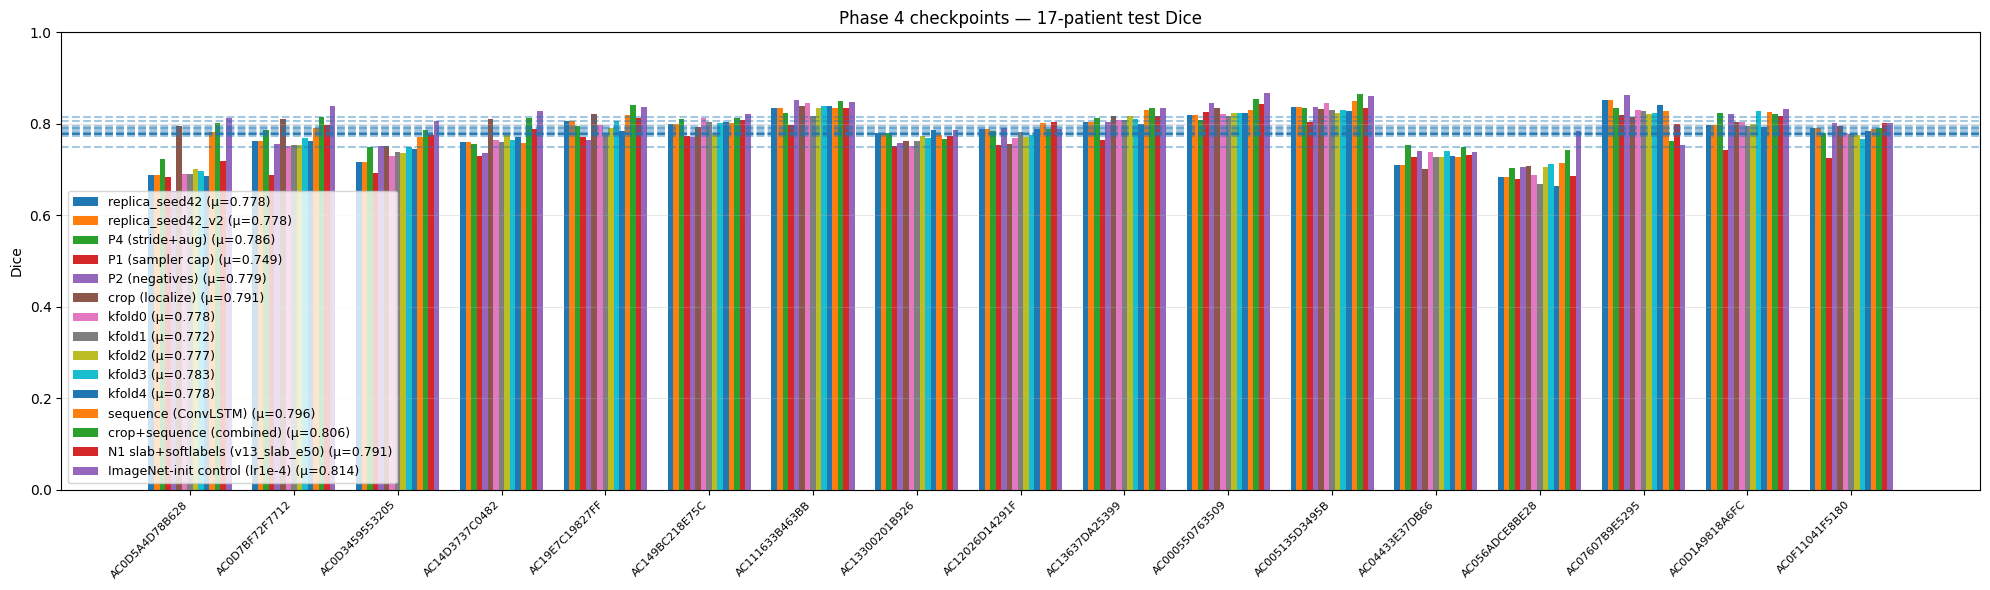

In [23]:
fig, ax = plt.subplots(figsize=(20, 6))
x = np.arange(len(df))
labels = [l for l in RUNS_INFO if df[l].notna().any()]
w = 0.8 / max(len(labels), 1)
for i, label in enumerate(labels):
    ax.bar(x + i * w, df[label], w, label=f"{label} (μ={means[label]:.3f})")
    ax.axhline(means[label], linestyle="--", alpha=0.4)
ax.set_xticks(x + w * (len(labels) - 1) / 2)
ax.set_xticklabels(df["patient"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Dice"); ax.set_ylim(0, 1.0)
ax.set_title("Phase 4 checkpoints — 17-patient test Dice")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Section 2 — Validation Dice (2 real-val patients, from `history.csv`)

No inference needed here — every Phase 4 run already logs per-patient validation Dice at its own best epoch (the `dice_va_<pid>` columns in `history.csv`, same format across the replica, P4, P1, P2). This is the number `ckpt_best.pth` was actually selected on.

**Caveat — k-fold rows:** `best_epoch_val_dice()` below hardcodes `VAL_PATIENTS` to the 2 fixed replica-val patients. Each `run_v7_kfold{0-4}` was trained on a DIFFERENT 3-patient held-out fold, so those patients are not `VAL_PATIENTS` and `dice_va_{p}` will not exist in a kfold run's `history.csv` — the `.get(..., "nan")` fallback means this returns `nan` for the kfold rows, not a crash, but the numbers are meaningless for k-fold. The right tool for k-fold's actual question (per-patient CI over all 15 real-PD patients, each in its own held-out fold) is `scripts/aggregate_kfold_results.py` → `results/phase4_6_kfold.csv`, not this section.

In [24]:
def best_epoch_val_dice(history_path):
    """Returns (best_epoch, dice_real_va, {pid: dice_va_pid}, dice_real_tr, gap) at
    the epoch the val-Dice column is maximized -- same criterion ckpt_best.pth uses.
    Falls back to "dice_va"/"dice_tr" (finetune_meniscus_imagenet_control.py's
    simpler schema -- no fake-PD branch, so no dice_real_* columns) when
    "dice_real_va"/"dice_real_tr" aren't present (finetune_meniscus_v7_replica.py
    and finetune_meniscus_v13_slab.py's schema)."""
    if not os.path.exists(history_path):
        return None
    rows = list(csv.DictReader(open(history_path)))
    va_col = "dice_real_va" if "dice_real_va" in rows[0] else "dice_va"
    tr_col = "dice_real_tr" if "dice_real_tr" in rows[0] else "dice_tr"
    best = max(rows, key=lambda r: float(r[va_col]))
    per_pid = {p: float(best.get(f"dice_va_{p}", "nan")) for p in VAL_PATIENTS}
    return {
        "best_epoch": int(best["epoch"]),
        "dice_real_va": float(best[va_col]),
        "dice_real_tr": float(best[tr_col]),
        "gap": float(best["gap"]),
        **{f"val_{p}": v for p, v in per_pid.items()},
    }

val_rows = []
for label, (_, run_dir) in RUNS_INFO.items():
    info = best_epoch_val_dice(os.path.join(run_dir, "history.csv"))
    if info is None:
        print(f"{label:<18}: history.csv not found under {run_dir}")
        continue
    val_rows.append({"run": label, **info})

val_df = pd.DataFrame(val_rows)
val_df

crop (localize)   : history.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_crop
kfold0            : history.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_kfold0
kfold1            : history.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_kfold1
kfold2            : history.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_kfold2
kfold3            : history.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_kfold3
kfold4            : history.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_kfold4


,run,best_epoch,dice_real_va,dice_real_tr,gap,val_AC0CE315D5758B,val_AC0CEE9C24F2B7
0,replica_seed42,10,0.78091,0.92470,0.14379,0.75450,0.75063
1,replica_seed42_v2,10,0.78091,0.92470,0.14379,0.75450,0.75063
2,P4 (stride+aug),15,0.78990,0.93629,0.14639,0.77216,0.75959
3,P1 (sampler cap),19,0.74295,0.84296,0.10001,0.71737,0.71230
4,P2 (negatives),13,0.79426,0.93604,0.14178,0.79435,0.72884
5,sequence (ConvLSTM),19,0.79494,0.94734,0.15240,0.77579,0.77067
6,crop+sequence (combined),12,0.80674,0.92971,0.12297,0.77733,0.79683
7,N1 slab+softlabels (v13_slab_e50),19,0.79301,0.94836,0.15534,0.77688,0.76641
8,ImageNet-init control (lr1e-4),6,0.84596,0.94267,0.09671,0.82235,0.80922


In [25]:
# Test Dice (Section 1) vs Validation Dice (Section 2), side by side.
# Noise floor from the seed-42/seed-7 comparison: per-patient max |delta| = 0.0226.
# Any difference smaller than that between runs is not distinguishable from chance.
NOISE_FLOOR = 0.0226

combined = val_df[["run", "dice_real_va", "gap", "best_epoch"]].copy()
combined["test_17pt_mean"] = combined["run"].map(means.to_dict())
combined["test_minus_val"] = combined["test_17pt_mean"] - combined["dice_real_va"]
print(f"Noise floor (seed42 vs seed7, per-patient max |delta|): {NOISE_FLOOR}")
print("Differences vs the replica smaller than this are not distinguishable from chance.\n")
combined

Noise floor (seed42 vs seed7, per-patient max |delta|): 0.0226
Differences vs the replica smaller than this are not distinguishable from chance.



,run,dice_real_va,gap,best_epoch,test_17pt_mean,test_minus_val
0,replica_seed42,0.78091,0.14379,10,0.778037,-0.002873
1,replica_seed42_v2,0.78091,0.14379,10,0.778037,-0.002873
2,P4 (stride+aug),0.78990,0.14639,15,0.785578,-0.004322
3,P1 (sampler cap),0.74295,0.10001,19,0.748884,0.005934
4,P2 (negatives),0.79426,0.14178,13,0.779457,-0.014803
5,sequence (ConvLSTM),0.79494,0.15240,19,0.795832,0.000892
6,crop+sequence (combined),0.80674,0.12297,12,0.805739,-0.001001
7,N1 slab+softlabels (v13_slab_e50),0.79301,0.15534,19,0.790600,-0.002410
8,ImageNet-init control (lr1e-4),0.84596,0.09671,6,0.814305,-0.031655


## Section 2b — Fake-PD Validation Dice (per patient, where saved)

Every fine-tuning run also has a fake-PD (synthetic DESS→PD) validation split, logged as an aggregate (`dice_fake_va` in `history.csv`) but never broken out per patient in this notebook until now. This isn't the target metric (real PD is), but it's a useful sanity check: if a change helps real-val/test Dice while hurting fake-val Dice (or vice versa), that's worth knowing -- it can mean a fix is exploiting something domain-specific rather than fixing the underlying segmentation problem.

Per-patient breakdown requires each run to have dumped `fake_val_per_slice_dice.csv` (written by `dump_val_predictions()` in the training scripts, next to `val_predictions/`) -- **not every run has this file pulled locally**, so this section only computes for the runs where it's present and reports "not found" for the rest, same pattern as Section 2.

In [26]:
def fake_val_dice_per_patient(run_dir):
    """Aggregates fake_val_per_slice_dice.csv into per-patient Dice using the
    same tp/gt_px/pred_px sum-then-divide convention as the training script's
    eval_real_per_patient() (NOT a mean of per-slice Dice -- that would over-
    weight small/empty slices). Returns None if the file isn't present."""
    path = os.path.join(run_dir, "fake_val_per_slice_dice.csv")
    if not os.path.exists(path):
        return None
    rows = list(csv.DictReader(open(path)))
    agg = {}
    for r in rows:
        gt = int(float(r["gt_voxels"])); pred = int(float(r["pred_voxels"])); fn = int(float(r["false_neg"]))
        tp = gt - fn
        a = agg.setdefault(r["patient_id"], [0, 0, 0])
        a[0] += tp; a[1] += gt; a[2] += pred
    eps = 1e-6
    per_patient = {pid: (2 * tp + eps) / (gt + pred + eps) for pid, (tp, gt, pred) in agg.items()}
    return per_patient

fake_val_rows = []
fake_val_per_patient_by_run = {}
for label, (_, run_dir) in RUNS_INFO.items():
    per_patient = fake_val_dice_per_patient(run_dir)
    if per_patient is None:
        print(f"{label:<18}: fake_val_per_slice_dice.csv not found under {run_dir}")
        continue
    fake_val_per_patient_by_run[label] = per_patient
    mean_dice = float(np.mean(list(per_patient.values())))
    worst_pid = min(per_patient, key=per_patient.get)
    fake_val_rows.append({
        "run": label,
        "fake_val_mean": mean_dice,
        "n_fake_val_patients": len(per_patient),
        "worst_patient": worst_pid,
        "worst_patient_dice": per_patient[worst_pid],
    })

fake_val_df = pd.DataFrame(fake_val_rows)
fake_val_df

P4 (stride+aug)   : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_p4
P1 (sampler cap)  : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_p1
P2 (negatives)    : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_p2
crop (localize)   : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_crop
kfold0            : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_kfold0
kfold1            : fake_val_per_slice_dice.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_kfold1
kfold2            : fake_val_per_slice_dice.csv not fo

,run,fake_val_mean,n_fake_val_patients,worst_patient,worst_patient_dice
0,replica_seed42,0.748792,15,MTR_230,0.573722
1,replica_seed42_v2,0.748792,15,MTR_230,0.573722


In [27]:
# Full per-patient breakdown, for the runs that have it -- and a cross-check
# against history.csv's own aggregate dice_fake_va (they won't match exactly,
# same reason the real-val numbers don't match dice_real_va: dice_fake_va is a
# batch-by-batch running average during training, this is a clean end-of-epoch
# per-patient pass).
if fake_val_per_patient_by_run:
    fake_val_wide = pd.DataFrame(fake_val_per_patient_by_run).sort_index()
    print("Per-patient fake-PD val Dice (runs with fake_val_per_slice_dice.csv):")
    display(fake_val_wide.round(4))

    print("\nCross-check vs history.csv's dice_fake_va aggregate:")
    for label, (_, run_dir) in RUNS_INFO.items():
        if label not in fake_val_per_patient_by_run:
            continue
        hist_path = os.path.join(run_dir, "history.csv")
        rows = list(csv.DictReader(open(hist_path)))
        va_col = "dice_real_va" if "dice_real_va" in rows[0] else "dice_va"
        best = max(rows, key=lambda r: float(r[va_col]))
        hist_fake_va = float(best.get("dice_fake_va", "nan"))
        clean_mean = fake_val_df.loc[fake_val_df["run"] == label, "fake_val_mean"].iloc[0]
        print(f"  {label:<18}: history.csv dice_fake_va={hist_fake_va:.4f}   "
              f"clean per-patient mean={clean_mean:.4f}   diff={clean_mean - hist_fake_va:+.4f}")
else:
    print("No run has fake_val_per_slice_dice.csv locally yet.")

Per-patient fake-PD val Dice (runs with fake_val_per_slice_dice.csv):


,replica_seed42,replica_seed42_v2
MTR_026,0.7918,0.7918
MTR_033,0.8027,0.8027
MTR_038,0.8218,0.8218
MTR_053,0.7747,0.7747
MTR_057,0.7776,0.7776
MTR_083,0.7442,0.7442
MTR_156,0.7915,0.7915
MTR_172,0.7069,0.7069
MTR_174,0.7706,0.7706
MTR_203,0.6781,0.6781



Cross-check vs history.csv's dice_fake_va aggregate:
  replica_seed42    : history.csv dice_fake_va=0.7598   clean per-patient mean=0.7488   diff=-0.0110
  replica_seed42_v2 : history.csv dice_fake_va=0.7598   clean per-patient mean=0.7488   diff=-0.0110


## Section 3 — Comparative ranking (17pt test Dice vs replica, vs noise floor)

Every run's mean 17pt test Dice, ranked, with its delta against `replica_seed42` judged against the 0.0226 per-patient noise floor established from the seed42-vs-seed7 comparison (`docs/phase4_results.md` step 5). `replica_seed42_v2` should land at ~0 delta — it's the SAME checkpoint re-inferred, a control check that the pipeline is deterministic and reproducible, not a real comparison point. K-fold rows are each a different checkpoint trained on a different 12-patient subset (holding out a different fold) than the replica's fixed 13/2 split, so their deltas here answer "how does this fold's checkpoint do on the 17pt set," not a clean one-change-at-a-time comparison — `results/phase4_6_kfold.csv` (via `aggregate_kfold_results.py`) is the tool for k-fold's real question (per-patient CV Dice on held-out folds).

In [28]:
NOISE_FLOOR = 0.0226
baseline_label = "replica_seed42"

rank_rows = []
for label in RUNS_INFO:
    if label not in means.index or np.isnan(means[label]):
        continue
    delta = means[label] - means[baseline_label]
    rank_rows.append({
        "run": label,
        "test_17pt_mean": round(means[label], 4),
        "delta_vs_replica": round(delta, 4),
        "above_noise_floor": abs(delta) > NOISE_FLOOR,
        "direction": ("real gain" if delta > NOISE_FLOOR else
                      "real loss" if delta < -NOISE_FLOOR else
                      "noise / no effect"),
    })

rank_df = pd.DataFrame(rank_rows).sort_values("test_17pt_mean", ascending=False).reset_index(drop=True)
print(f"Baseline: {baseline_label} = {means[baseline_label]:.4f}   |   noise floor = ±{NOISE_FLOOR}")
rank_df

Baseline: replica_seed42 = 0.7780   |   noise floor = ±0.0226


,run,test_17pt_mean,delta_vs_replica,above_noise_floor,direction
0,ImageNet-init control (lr1e-4),0.8143,0.0363,True,real gain
1,crop+sequence (combined),0.8057,0.0277,True,real gain
2,sequence (ConvLSTM),0.7958,0.0178,False,noise / no effect
3,crop (localize),0.7910,0.0129,False,noise / no effect
4,N1 slab+softlabels (v13_slab_e50),0.7906,0.0126,False,noise / no effect
5,P4 (stride+aug),0.7856,0.0075,False,noise / no effect
6,kfold3,0.7827,0.0047,False,noise / no effect
7,P2 (negatives),0.7795,0.0014,False,noise / no effect
8,kfold4,0.7783,0.0002,False,noise / no effect
9,replica_seed42,0.7780,0.0000,False,noise / no effect


/var/folders/bc/g2l1lwnx4cg8sszchc8lfgs00000gn/T/ipykernel_1316/3559324887.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rank_df["run"], rotation=45, ha="right")


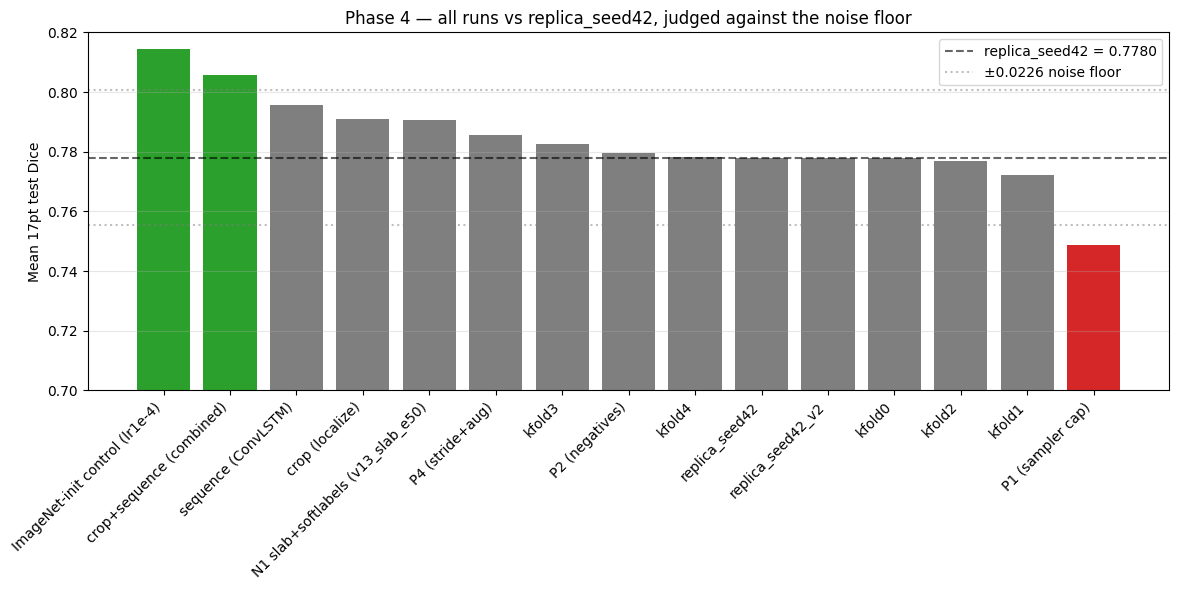


/Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/results/phase4_6_kfold.csv not found yet -- run scripts/aggregate_kfold_results.py once all 5 folds' inference+val data is pulled, for k-fold's real per-patient CI question.


In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = {"real gain": "tab:green", "real loss": "tab:red", "noise / no effect": "tab:gray"}
bar_colors = [colors[d] for d in rank_df["direction"]]
ax.bar(rank_df["run"], rank_df["test_17pt_mean"], color=bar_colors)
ax.axhline(means[baseline_label], linestyle="--", color="black", alpha=0.6, label=f"{baseline_label} = {means[baseline_label]:.4f}")
ax.axhline(means[baseline_label] + NOISE_FLOOR, linestyle=":", color="gray", alpha=0.5)
ax.axhline(means[baseline_label] - NOISE_FLOOR, linestyle=":", color="gray", alpha=0.5, label=f"±{NOISE_FLOOR} noise floor")
ax.set_ylabel("Mean 17pt test Dice")
ax.set_ylim(0.7, 0.82)
ax.set_title("Phase 4 — all runs vs replica_seed42, judged against the noise floor")
ax.set_xticklabels(rank_df["run"], rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

if os.path.exists(f"{RES}/phase4_6_kfold.csv"):
    print("\nk-fold's real per-patient CV result (separate from the ranking above):")
    print(pd.read_csv(f"{RES}/phase4_6_kfold.csv"))
else:
    print(f"\n{RES}/phase4_6_kfold.csv not found yet -- run scripts/aggregate_kfold_results.py "
          f"once all 5 folds' inference+val data is pulled, for k-fold's real per-patient CI question.")